## Crazy idea: Low-pass filter the signal before CWT. Will the sqrt(f) dependence of noise amplitude disappear?

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../../wavelet/')
import wavelet_funcs as wf

path.append('../../signals/')
import signals as sg

import matlab.engine

from scipy.ndimage import gaussian_filter1d

In [3]:
eng = matlab.engine.start_matlab()

# Synthetic signal:

$$
z = \cos(2\pi f_1 t) + \cos(2\pi f_2 t) + \epsilon,
$$

where $f_1=0.5\,$Hz, $f_2=2\,$Hz, and $\epsilon \sim N(0, 1)$ (white noise).

In [62]:
T = 500 # s
dt = 0.1 # s
Fs = 1/dt
nt = int(T/dt)
fsignals = np.array([0.5, 0.05])

t = np.arange(nt)*dt
x = np.array([sg.cosine(T, fsig, sampling_frequency=Fs, amplitude=1)[1] for fsig in fsignals])
x = x.sum(axis=0) # sum of cosines

y = np.random.randn(nt) # noise

z = x + y # noisy sum of cosines
z_filt = gaussian_filter1d(z, sigma=2)

In [63]:
cwt_z = wf.matlab_cwt(eng, z, Fs, voices_per_octave=24)
cwt_z_filt = wf.matlab_cwt(eng, z_filt, Fs, voices_per_octave=24)

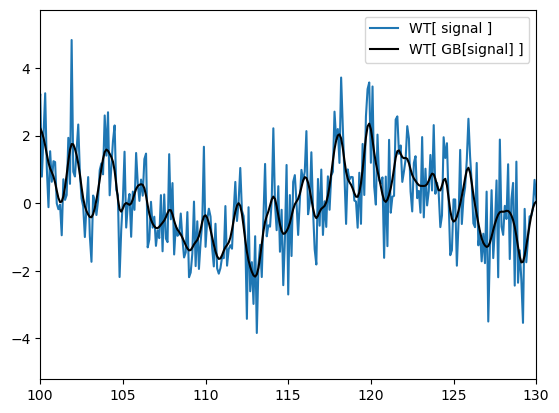

In [69]:
plt.plot(t,z, label='WT[ signal ]')
plt.plot(t, z_filt,color='k', label='WT[ GB[signal] ]')
plt.xlim(100, 130)
plt.legend()

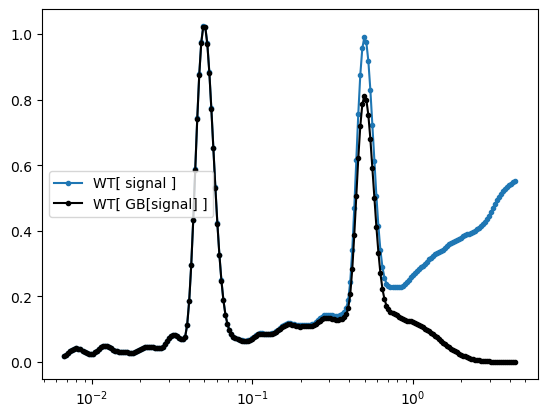

In [70]:
plt.plot(cwt_z.f, cwt_z.wt_amp.mean('t'), marker='.', label='WT[ signal ]')
plt.plot(cwt_z_filt.f, cwt_z_filt.wt_amp.mean('t'),color='k',marker='.', label='WT[ GB[signal] ]')
plt.xscale('log')
plt.legend()

Low-pass filtering removes only part of the noise, high-frequencies obviously, but lower-frequency noise remains, resulting in a background hill. Useless